# Final Model Evaluation

This notebook evaluates the final saved classical URA model from `results/final_model_training/final_ura_model.joblib`.

It rebuilds the final feature table, recreates the same ELY-stratified `Segment_ID` split, uses the saved model for test predictions, and produces comprehensive metrics, plots, and heavy-vehicle (`KVL_raskas`) analysis.

## 1. Configuration

In [1]:
from __future__ import annotations

from pathlib import Path
import inspect
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

RANDOM_STATE = 42
MODEL_DATA_PATH = Path("data/road_model_dataset_v2.parquet")
EVENT_HISTORY_PATH = Path("data/road_event_history_v2.parquet")
TRAINING_DIR = Path("results/final_model_training")
COMPARISON_DIR = Path("results/final_model_comparison")
RESULT_DIR = Path("results/final_model_evaluation")
FIGURE_DIR = RESULT_DIR / "figures"
TABLE_DIR = RESULT_DIR / "tables"
for path in [RESULT_DIR, FIGURE_DIR, TABLE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

PIPELINE_PATH = TRAINING_DIR / "final_ura_model.joblib"
METADATA_PATH = TRAINING_DIR / "final_ura_model_metadata.json"

TRAIN_FRACTION = 0.70
VALIDATION_FRACTION = 0.15
TEST_FRACTION = 0.15
HORIZON_WINDOWS = {"1y": (274, 457), "2y": (639, 822), "3y": (1004, 1187), "4y": (1370, 1553)}

print(f"Evaluation outputs: {RESULT_DIR.resolve()}")

Evaluation outputs: C:\Users\Gamer2\Documents\school_sync\misc_maisteri_kurssit\case_studies_operations_research\Vayla_projekti\results\final_model_evaluation


## 2. Load Saved Model And Metadata

In [2]:
if not PIPELINE_PATH.exists():
    raise FileNotFoundError(f"Final saved model not found: {PIPELINE_PATH}")
if not METADATA_PATH.exists():
    raise FileNotFoundError(f"Final model metadata not found: {METADATA_PATH}")

pipeline = joblib.load(PIPELINE_PATH)
with open(METADATA_PATH, "r", encoding="utf-8") as f:
    metadata = json.load(f)

TARGET = metadata["target"]
TARGET_TYPE = metadata["target_type"]
TRAIN_TARGET = metadata["train_target"]
CURRENT_TARGET_COL = metadata.get("current_target_col", "URA")
FEATURES = metadata["features"]

display(pd.DataFrame([metadata]))
print(pipeline)

,model,target,target_type,train_target,current_target_col,features,params,random_state
0,hist_gradient_boosting,target_next_URA,delta_converted_to_actual,delta_target_next_URA,URA,"[URA, IRI, target_horizon_years, KVL, KVL_rask...","{'learning_rate': 0.1, 'max_iter': 400, 'max_l...",42


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['URA', 'IRI',
                                                   'target_horizon_years',
                                                   'KVL', 'KVL_raskas',
                                                   'KVL_kaista', 'Nopeus',
                                                   'prev_URA', 'prev_IRI',
                                                   'Delta_t_years',
                                                   'observed_lifecycle_age_years',
                                                   'Minor_TP_Count',
                                                   'tp_count_interval',
                                                   'years_since_material_update']),
                                                 ('cat',
                                 

## 3. Rebuild Evaluation Dataset

In [3]:
MODEL_COLUMNS = [
    "Segment_ID", "Lifecycle_ID", "event_date", "ELY",
    "KVL", "KVL_raskas", "KVL_kaista", "Nopeus", "Toim_lk",
    "IRI", "URA", "prev_IRI", "prev_URA", "Delta_t_years",
    "Pavement_Age_years", "Minor_TP_Count", "tp_count_interval",
    "target_next_URA", "target_next_IRI", "target_horizon_days", "target_horizon_years",
]

df = pd.read_parquet(MODEL_DATA_PATH, columns=MODEL_COLUMNS)
df["event_date"] = pd.to_datetime(df["event_date"], errors="coerce")
df["observed_lifecycle_age_years"] = pd.to_numeric(df["Pavement_Age_years"], errors="coerce")

SURFACE_TYPE_MAP = {"ab": "AB", "abk": "AB", "abs": "AB", "ea": "AB", "pab-v": "PAB", "pab-b": "PAB", "pab-o": "PAB", "sma": "SMA"}
MATERIAL_TYPE_MAP = {"lta": "new", "mp": "new", "mpkj": "new", "art": "new", "mpk": "new", "rem": "recycled", "urem": "recycled", "remo": "recycled", "rem+": "recycled"}

def normalize_token(value):
    if pd.isna(value):
        return None
    token = str(value).strip().lower()
    return token if token else None

def classify_surface(value):
    token = normalize_token(value)
    return "unknown" if token is None else SURFACE_TYPE_MAP.get(token, "other")

def classify_material(value):
    token = normalize_token(value)
    return "unknown" if token is None else MATERIAL_TYPE_MAP.get(token, "other")

def add_current_material_state(model_df, event_history_path):
    cols = ["event_type", "Segment_ID", "event_date", "Tp_pinta", "Tp_tyomen", "tp_idx"]
    try:
        tp = pd.read_parquet(event_history_path, columns=cols, filters=[("event_type", "==", "TP")])
    except (TypeError, ValueError):
        events = pd.read_parquet(event_history_path, columns=cols)
        tp = events.loc[events["event_type"].eq("TP")].copy()
    tp = tp.dropna(subset=["Segment_ID", "event_date"]).copy()
    tp["event_date"] = pd.to_datetime(tp["event_date"], errors="coerce")
    tp = tp.dropna(subset=["event_date"])
    tp["surface_type_current"] = tp["Tp_pinta"].map(classify_surface)
    tp["material_type_current"] = tp["Tp_tyomen"].map(classify_material)
    tp["tp_idx"] = pd.to_numeric(tp["tp_idx"], errors="coerce")

    left = model_df.reset_index(names="_row_id").sort_values(["event_date", "Segment_ID"], kind="mergesort")
    right = (
        tp[["Segment_ID", "event_date", "tp_idx", "surface_type_current", "material_type_current"]]
        .sort_values(["event_date", "Segment_ID", "tp_idx"], kind="mergesort")
        .rename(columns={"event_date": "latest_material_event_date"})
    )
    merged = pd.merge_asof(
        left, right,
        left_on="event_date", right_on="latest_material_event_date",
        by="Segment_ID", direction="backward", allow_exact_matches=True,
    )
    merged["surface_type_current"] = merged["surface_type_current"].fillna("unknown")
    merged["material_type_current"] = merged["material_type_current"].fillna("unknown")
    merged["years_since_material_update"] = (merged["event_date"] - merged["latest_material_event_date"]).dt.days / 365.25
    return merged.sort_values("_row_id", kind="mergesort").drop(columns=["_row_id", "tp_idx"]).reset_index(drop=True)

df = add_current_material_state(df, EVENT_HISTORY_PATH)
print(f"Rows: {len(df):,}; segments: {df['Segment_ID'].nunique():,}")

Rows: 3,833,323; segments: 996,476


## 4. Recreate Split And Generate Predictions

In [4]:
def make_ely_segment_split(frame, train_frac, val_frac, test_frac, random_state):
    rng = np.random.default_rng(random_state)
    segment_split = {}
    segment_ely = frame[["Segment_ID", "ELY"]].drop_duplicates()
    if segment_ely["Segment_ID"].duplicated().any():
        raise ValueError("Segment_ID appears in multiple ELY groups.")
    for ely, group in segment_ely.groupby("ELY", sort=True):
        segments = group["Segment_ID"].to_numpy(copy=True)
        rng.shuffle(segments)
        n = len(segments)
        n_train = int(round(n * train_frac))
        n_val = int(round(n * val_frac))
        n_train = min(max(n_train, 1), n - 2)
        n_val = min(max(n_val, 1), n - n_train - 1)
        for seg in segments[:n_train]:
            segment_split[seg] = "train"
        for seg in segments[n_train:n_train + n_val]:
            segment_split[seg] = "validation"
        for seg in segments[n_train + n_val:]:
            segment_split[seg] = "test"
    return frame["Segment_ID"].map(segment_split).astype("category")

def metrics(y_true, y_pred):
    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": mean_squared_error(y_true, y_pred) ** 0.5,
        "r2": r2_score(y_true, y_pred),
    }

def convert_prediction(frame, raw_pred):
    if TARGET_TYPE == "delta_converted_to_actual":
        return frame[CURRENT_TARGET_COL].to_numpy() + raw_pred
    if TARGET_TYPE == "direct":
        return raw_pred
    raise ValueError(f"Unsupported target type: {TARGET_TYPE}")

df["split"] = make_ely_segment_split(df, TRAIN_FRACTION, VALIDATION_FRACTION, TEST_FRACTION, RANDOM_STATE)
assert df[["Segment_ID", "split"]].drop_duplicates().groupby("Segment_ID")["split"].nunique().max() == 1

test_frame = df.loc[df["split"].eq("test")].copy()
raw_pred = pipeline.predict(test_frame[FEATURES])
pred = convert_prediction(test_frame, raw_pred)

eval_df = test_frame[[
    "Segment_ID", "Lifecycle_ID", "ELY", "event_date", "target_horizon_days", "target_horizon_years",
    "URA", "IRI", "KVL", "KVL_raskas", "KVL_kaista", "Nopeus", "Toim_lk",
    "prev_URA", "prev_IRI", "Delta_t_years", "observed_lifecycle_age_years", "Minor_TP_Count",
    "tp_count_interval", "surface_type_current", "material_type_current", "years_since_material_update", TARGET,
]].copy()
eval_df["raw_model_prediction"] = raw_pred
eval_df["prediction"] = pred
eval_df["residual"] = eval_df[TARGET] - eval_df["prediction"]
eval_df["abs_error"] = eval_df["residual"].abs()
eval_df["actual_delta_URA"] = eval_df[TARGET] - eval_df["URA"]
eval_df["predicted_delta_URA"] = eval_df["prediction"] - eval_df["URA"]
eval_df["horizon_window"] = "outside_windows"
for name, (lo, hi) in HORIZON_WINDOWS.items():
    mask = eval_df["target_horizon_days"].between(lo, hi, inclusive="both")
    eval_df.loc[mask, "horizon_window"] = name

display(df["split"].value_counts().to_frame("rows"))
display(pd.DataFrame([{**metrics(eval_df[TARGET], eval_df["prediction"]), "rows": len(eval_df)}]))
eval_df.to_parquet(RESULT_DIR / "final_model_evaluation_predictions.parquet", index=False)

,rows
split,
train,2683410
test,575195
validation,574718


,mae,rmse,r2,rows
0,1.057844,1.643727,0.861921,575195


## 5. Overall Metrics And Comparison

,mae,rmse,r2,rows,model,target_type
0,1.057844,1.643727,0.861921,575195,hist_gradient_boosting,delta_converted_to_actual


,source,model,target,target_type,feature_mixture,train_rows,evaluation_rows,test_rows,mae,rmse,r2
8,final_training_saved_result,hist_gradient_boosting,target_next_URA,delta_converted_to_actual,NaN,3258128,NaN,575195.0,1.057844,1.643727,0.861921
6,direct_vs_delta_comparison,hist_gradient_boosting,target_next_URA,delta_converted_to_actual,current_static_lag_lifecycle_material,3258128,575195.0,NaN,1.144561,1.754246,0.842729
7,direct_vs_delta_comparison,hist_gradient_boosting,target_next_URA,direct,current_static_lag_lifecycle_material,3258128,575195.0,NaN,1.150635,1.765230,0.840754
0,final_model_comparison,hist_gradient_boosting,target_next_URA,direct,current_static_lag_lifecycle_material,3258128,575195.0,NaN,1.150635,1.765230,0.840754
1,final_model_comparison,random_forest,target_next_URA,direct,current_static_lag_lifecycle_material,300000,575195.0,NaN,1.141090,1.774198,0.839131
2,final_model_comparison,gradient_boosting,target_next_URA,direct,current_static_lag_lifecycle_material,150000,575195.0,NaN,1.209294,1.841161,0.826759
3,final_model_comparison,linear_regression,target_next_URA,direct,current_static_lag_lifecycle_material,3258128,575195.0,NaN,1.286372,1.923522,0.810913
4,final_model_comparison,ridge,target_next_URA,direct,current_static_lag_lifecycle_material,3258128,575195.0,NaN,1.286372,1.923522,0.810913
5,final_model_comparison,persistence,target_next_URA,direct,persistence,3258128,575195.0,NaN,1.894494,2.645991,0.642197


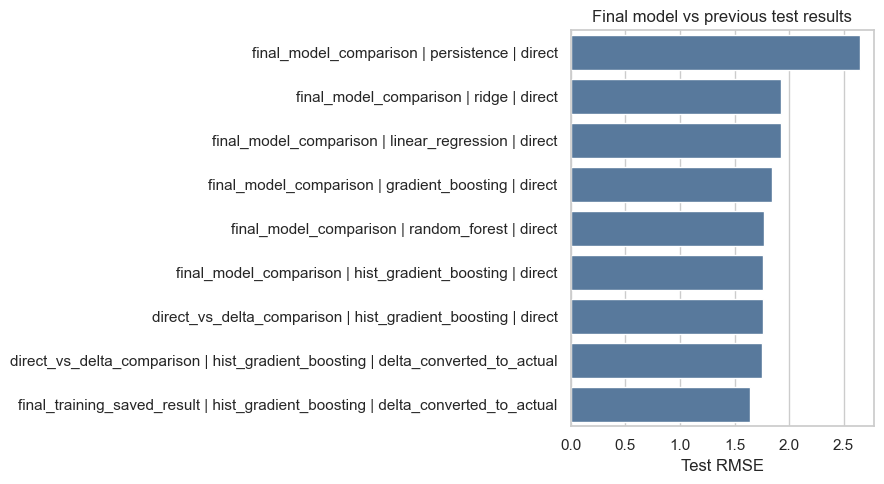

In [5]:
overall_result = pd.DataFrame([{**metrics(eval_df[TARGET], eval_df["prediction"]), "rows": len(eval_df), "model": metadata["model"], "target_type": TARGET_TYPE}])
display(overall_result)
overall_result.to_csv(TABLE_DIR / "overall_metrics.csv", index=False)

comparison_tables = []
for path, label in [
    (COMPARISON_DIR / "test_results_overall.csv", "final_model_comparison"),
    (COMPARISON_DIR / "direct_vs_delta_test_results.csv", "direct_vs_delta_comparison"),
    (TRAINING_DIR / "final_ura_model_test_result.csv", "final_training_saved_result"),
]:
    if path.exists():
        tmp = pd.read_csv(path)
        tmp = tmp.loc[tmp["target"].eq(TARGET)].copy()
        tmp["source"] = label
        comparison_tables.append(tmp)

comparison_df = pd.concat(comparison_tables, ignore_index=True, sort=False).sort_values("rmse")
display(comparison_df[[c for c in ["source", "model", "target", "target_type", "feature_mixture", "train_rows", "evaluation_rows", "test_rows", "mae", "rmse", "r2"] if c in comparison_df.columns]])
comparison_df.to_csv(TABLE_DIR / "comparison_against_prior_results.csv", index=False)

plot_cmp = comparison_df.head(12).copy()
plot_cmp["label"] = plot_cmp["source"] + " | " + plot_cmp["model"].astype(str) + " | " + plot_cmp["target_type"].fillna("direct")
plt.figure(figsize=(9, 5))
sns.barplot(data=plot_cmp.sort_values("rmse", ascending=False), y="label", x="rmse", color="#4C78A8")
plt.title("Final model vs previous test results")
plt.xlabel("Test RMSE")
plt.ylabel("")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "final_model_vs_previous_results.png", dpi=160)
plt.show()

## 6. Breakdown Tables

In [6]:
breakdown_rows = []
for group_type, col in [
    ("overall", None),
    ("horizon_window", "horizon_window"),
    ("ELY", "ELY"),
    ("surface_type_current", "surface_type_current"),
    ("material_type_current", "material_type_current"),
    ("Toim_lk", "Toim_lk"),
]:
    groups = [("overall", eval_df)] if col is None else eval_df.groupby(col, sort=True, dropna=False)
    for value, sub in groups:
        if value == "outside_windows" or len(sub) < 100:
            continue
        breakdown_rows.append({
            "group_type": group_type,
            "group": value,
            "rows": len(sub),
            "mean_actual": sub[TARGET].mean(),
            "mean_prediction": sub["prediction"].mean(),
            "mean_actual_delta": sub["actual_delta_URA"].mean(),
            "mean_predicted_delta": sub["predicted_delta_URA"].mean(),
            **metrics(sub[TARGET], sub["prediction"]),
        })

breakdown_df = pd.DataFrame(breakdown_rows).sort_values(["group_type", "rmse"])
display(breakdown_df)
breakdown_df.to_csv(TABLE_DIR / "breakdown_metrics.csv", index=False)

,group_type,group,rows,mean_actual,mean_prediction,mean_actual_delta,mean_predicted_delta,mae,rmse,r2
12,ELY,Uud,113991,8.904953,8.923258,1.703841,1.722145,0.916713,1.401476,0.899574
9,ELY,Pir,45640,9.669273,9.645113,1.803289,1.779130,0.961278,1.446003,0.900064
5,ELY,Epo,61939,8.834188,8.792104,1.759060,1.716975,1.036249,1.521239,0.868457
7,ELY,Kes,33919,8.781730,8.790124,1.605967,1.614361,1.025959,1.535571,0.862417
6,ELY,Kas,31743,7.913524,7.940580,1.533548,1.560604,0.977235,1.545083,0.882578
13,ELY,Var,69179,8.302174,8.283602,1.643795,1.625223,1.008883,1.646149,0.859651
11,ELY,Pos,85984,8.884068,8.887249,1.601776,1.604957,1.098334,1.721208,0.848728
10,ELY,Pop,78330,8.195892,8.182371,1.695450,1.681929,1.196544,1.831790,0.816791
8,ELY,Lap,54470,8.222535,8.216676,1.716565,1.710706,1.324306,2.057712,0.805580
25,Toim_lk,valta,174434,9.194535,9.187595,1.856909,1.849969,0.811566,1.183299,0.913427


## 7. Core Prediction Figures

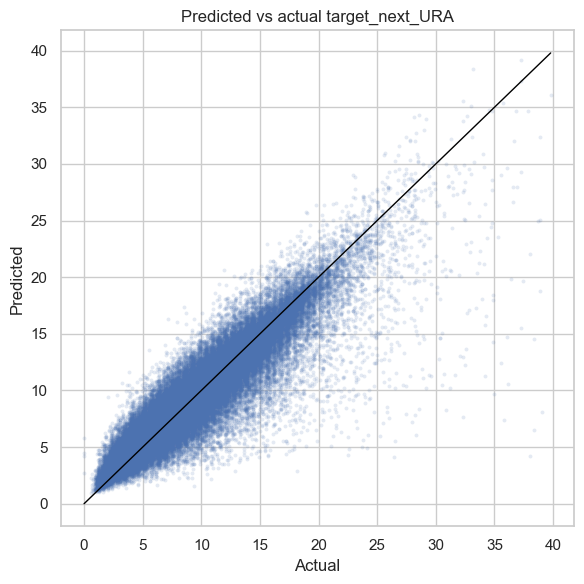

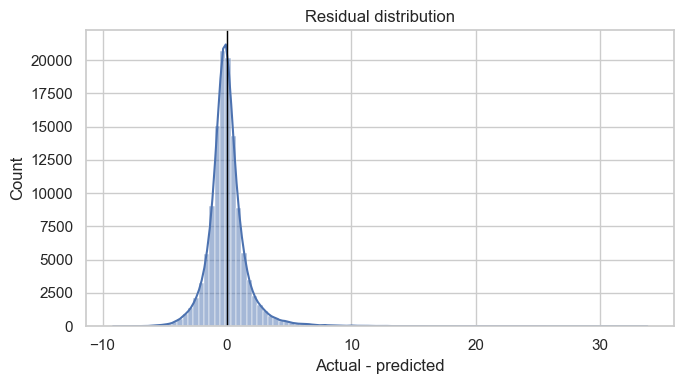

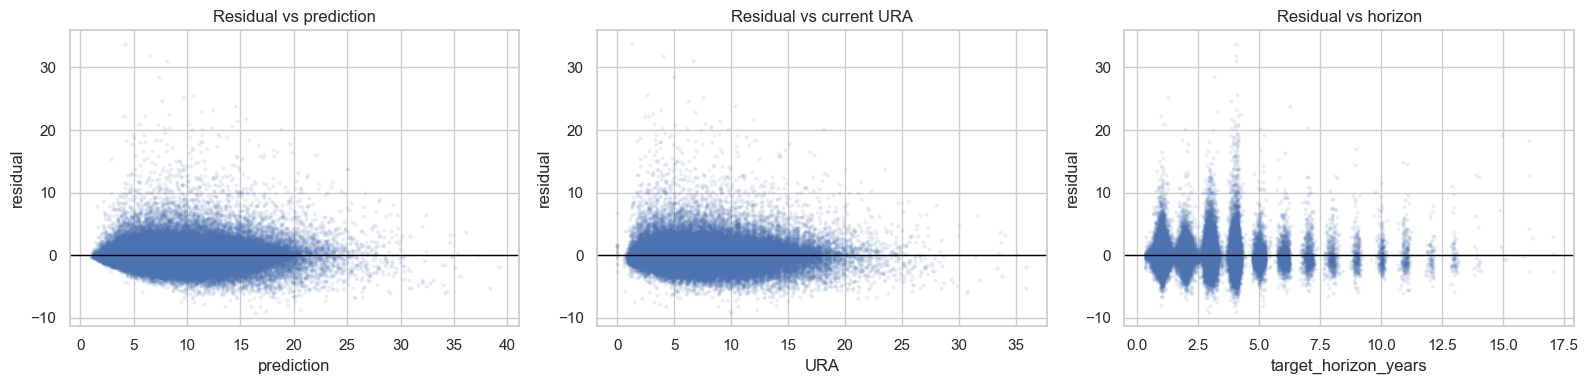

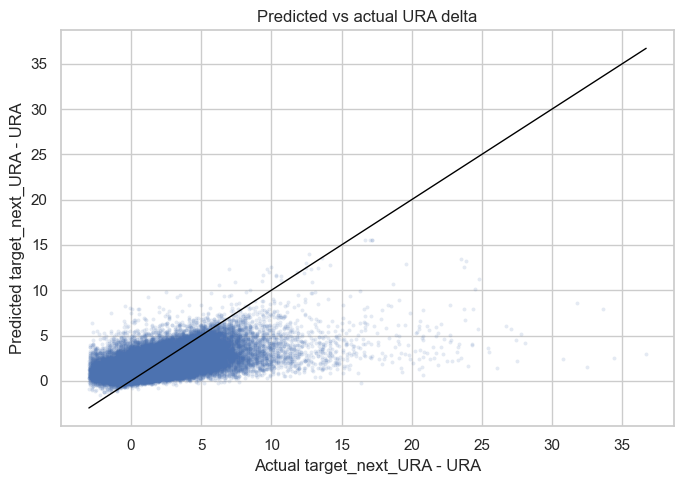

In [7]:
plot_sample = eval_df.sample(min(len(eval_df), 120_000), random_state=RANDOM_STATE)

plt.figure(figsize=(6, 6))
sns.scatterplot(data=plot_sample, x=TARGET, y="prediction", alpha=0.15, s=8, linewidth=0)
lims = [min(plot_sample[TARGET].min(), plot_sample["prediction"].min()), max(plot_sample[TARGET].max(), plot_sample["prediction"].max())]
plt.plot(lims, lims, color="black", linewidth=1)
plt.title("Predicted vs actual target_next_URA")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "predicted_vs_actual.png", dpi=160)
plt.show()

plt.figure(figsize=(7, 4))
sns.histplot(plot_sample["residual"], bins=100, kde=True)
plt.axvline(0, color="black", linewidth=1)
plt.title("Residual distribution")
plt.xlabel("Actual - predicted")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "residual_distribution.png", dpi=160)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.scatterplot(data=plot_sample, x="prediction", y="residual", alpha=0.12, s=8, linewidth=0, ax=axes[0])
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Residual vs prediction")
sns.scatterplot(data=plot_sample, x="URA", y="residual", alpha=0.12, s=8, linewidth=0, ax=axes[1])
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Residual vs current URA")
sns.scatterplot(data=plot_sample, x="target_horizon_years", y="residual", alpha=0.12, s=8, linewidth=0, ax=axes[2])
axes[2].axhline(0, color="black", linewidth=1)
axes[2].set_title("Residual vs horizon")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "residual_diagnostics.png", dpi=160)
plt.show()

plt.figure(figsize=(7, 5))
sns.scatterplot(data=plot_sample, x="actual_delta_URA", y="predicted_delta_URA", alpha=0.15, s=8, linewidth=0)
delta_lims = [min(plot_sample["actual_delta_URA"].min(), plot_sample["predicted_delta_URA"].min()), max(plot_sample["actual_delta_URA"].max(), plot_sample["predicted_delta_URA"].max())]
plt.plot(delta_lims, delta_lims, color="black", linewidth=1)
plt.title("Predicted vs actual URA delta")
plt.xlabel("Actual target_next_URA - URA")
plt.ylabel("Predicted target_next_URA - URA")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "predicted_vs_actual_delta.png", dpi=160)
plt.show()

## 8. Horizon, ELY, And Material Figures

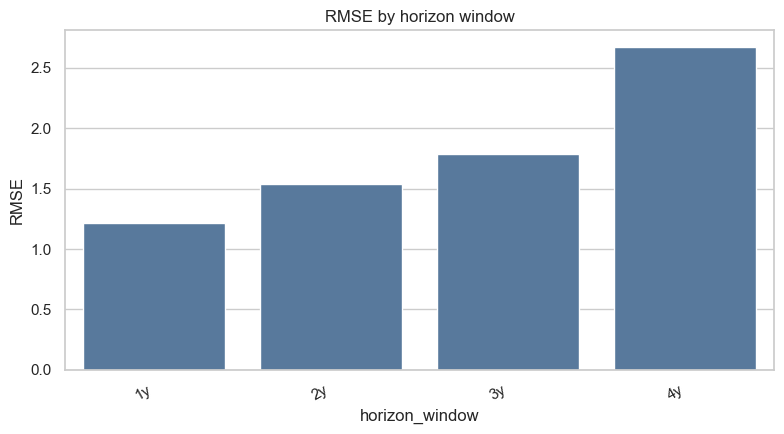

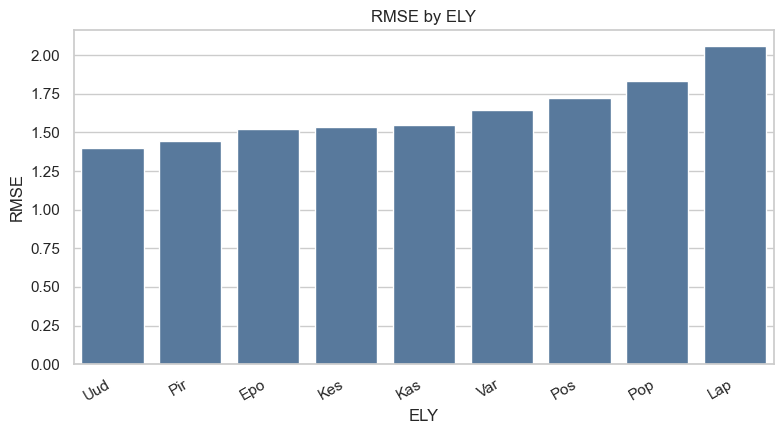

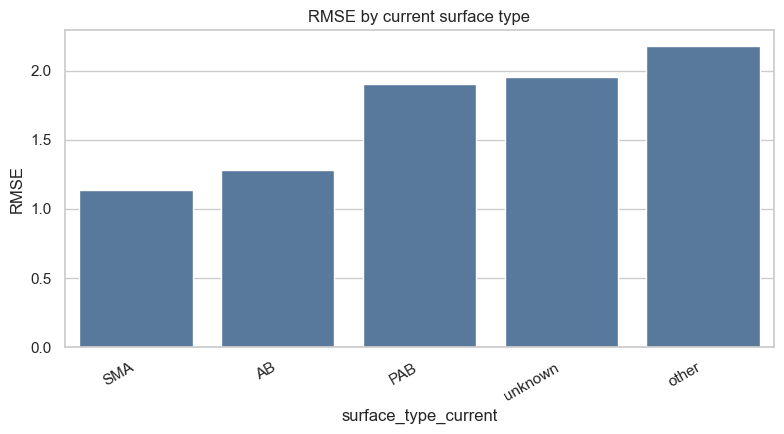

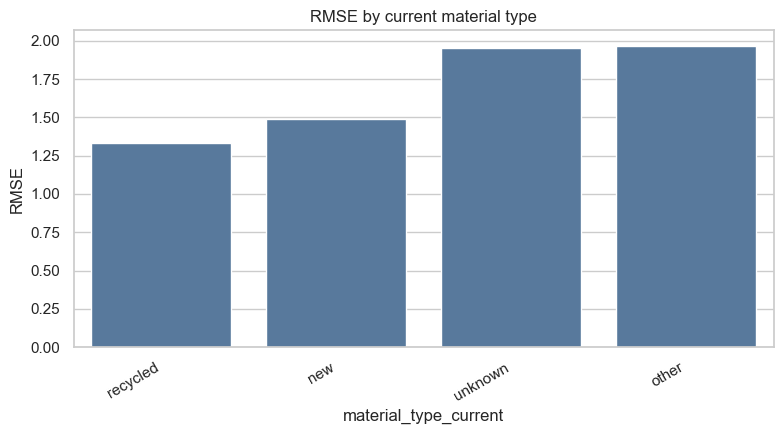

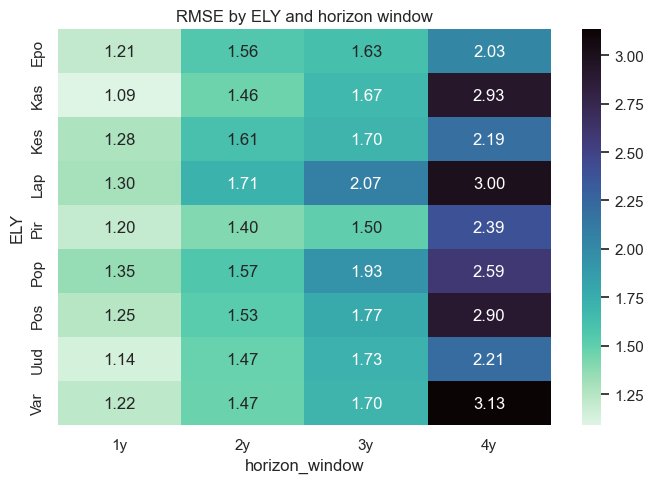

In [8]:
for group_type, filename, title, order in [
    ("horizon_window", "rmse_by_horizon_window.png", "RMSE by horizon window", ["1y", "2y", "3y", "4y"]),
    ("ELY", "rmse_by_ely.png", "RMSE by ELY", None),
    ("surface_type_current", "rmse_by_surface_type.png", "RMSE by current surface type", None),
    ("material_type_current", "rmse_by_material_type.png", "RMSE by current material type", None),
]:
    plot_df = breakdown_df.loc[breakdown_df["group_type"].eq(group_type)].copy()
    if order is None:
        plot_df = plot_df.sort_values("rmse")
        order = plot_df["group"].tolist()
    plt.figure(figsize=(8, 4.5))
    sns.barplot(data=plot_df, x="group", y="rmse", order=order, color="#4C78A8")
    plt.title(title)
    plt.xlabel(group_type)
    plt.ylabel("RMSE")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / filename, dpi=160)
    plt.show()

heat = eval_df.loc[eval_df["horizon_window"].ne("outside_windows")].groupby(["ELY", "horizon_window"]).apply(
    lambda g: metrics(g[TARGET], g["prediction"])["rmse"] if len(g) >= 100 else np.nan
).reset_index(name="rmse")
pivot = heat.pivot(index="ELY", columns="horizon_window", values="rmse").reindex(columns=["1y", "2y", "3y", "4y"])
plt.figure(figsize=(7, 5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="mako_r")
plt.title("RMSE by ELY and horizon window")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "rmse_heatmap_ely_horizon.png", dpi=160)
plt.show()

## 9. Calibration And Error Concentration

,prediction_bin,rows,mean_prediction,mean_actual,mean_residual,rmse
0,"(0.585, 3.216]",28760,2.615302,2.584913,-0.030389,0.889966
1,"(3.216, 3.952]",28760,3.601314,3.549006,-0.052308,1.107811
2,"(3.952, 4.544]",28760,4.256956,4.201801,-0.055155,1.236164
3,"(4.544, 5.076]",28759,4.811717,4.770267,-0.041451,1.296221
4,"(5.076, 5.579]",28760,5.328276,5.308081,-0.020196,1.401862
5,"(5.579, 6.066]",28760,5.822363,5.799312,-0.023051,1.433201
6,"(6.066, 6.545]",28759,6.306457,6.290243,-0.016214,1.466639
7,"(6.545, 7.028]",28760,6.785211,6.765553,-0.019658,1.506295
8,"(7.028, 7.523]",28760,7.274489,7.278070,0.003581,1.566390
9,"(7.523, 8.031]",28760,7.774799,7.796937,0.022137,1.621539


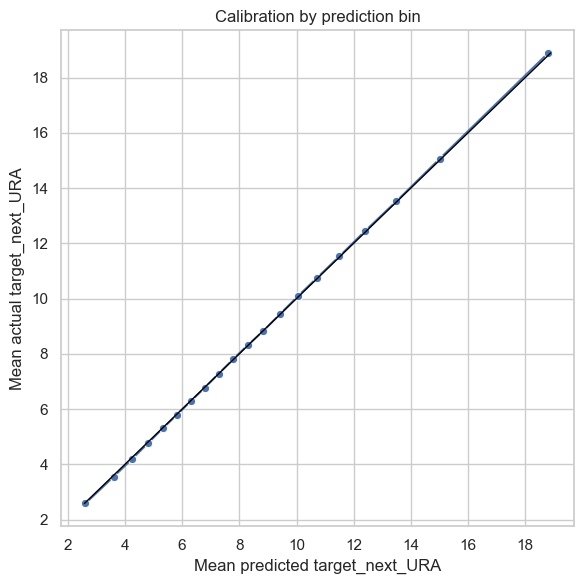

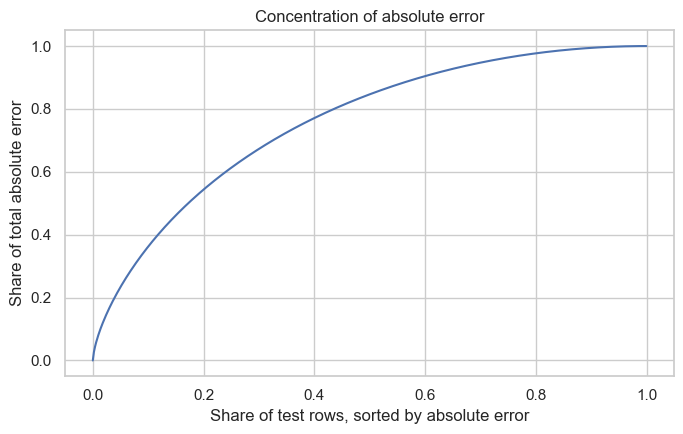

,Segment_ID,ELY,event_date,target_horizon_days,URA,target_next_URA,prediction,residual,abs_error,KVL_raskas
0,Kas_14809_0_11_1_200_1_300,Kas,2018-07-03,1478.0,1.3,38.0,4.221946,33.778054,33.778054,2.0
1,Var_12001_0_21_1_2400_1_2500,Var,2018-07-15,1442.0,3.1,37.8,4.338506,33.461494,33.461494,4.0
2,Pos_15370_0_11_2_600_2_700,Pos,2018-08-02,1480.0,4.0,38.4,6.505496,31.894504,31.894504,14.0
3,Pos_15639_0_21_2_1200_2_1300,Pos,2018-07-30,1481.0,2.5,37.0,5.498598,31.501402,31.501402,15.0
4,Kas_3921_0_11_3_4100_3_4200,Kas,2018-07-04,1478.0,6.6,39.1,8.110078,30.989922,30.989922,27.0
5,Uud_104_0_11_10_1100_10_1200,Uud,2019-05-20,1116.0,9.2,39.7,11.022431,28.677569,28.677569,41.0
6,Var_12691_0_11_3_3700_3_3800,Var,2020-05-18,1143.0,5.0,35.8,7.396854,28.403146,28.403146,27.0
7,Var_12138_0_11_1_0_1_100,Var,2018-07-24,1496.0,3.6,34.9,6.664351,28.235649,28.235649,9.0
8,Var_12295_0_11_1_2600_1_2700,Var,2018-06-14,1471.0,1.8,37.3,9.567380,27.732620,27.732620,10.0
9,Kes_16631_0_11_1_1100_1_1200,Kes,2020-05-31,713.0,8.4,37.2,9.938675,27.261325,27.261325,146.0


In [9]:
calib = eval_df.copy()
calib["prediction_bin"] = pd.qcut(calib["prediction"], q=20, duplicates="drop")
calib_summary = calib.groupby("prediction_bin", observed=False).agg(
    rows=(TARGET, "size"),
    mean_prediction=("prediction", "mean"),
    mean_actual=(TARGET, "mean"),
    mean_residual=("residual", "mean"),
    rmse=("residual", lambda x: np.sqrt(np.mean(np.square(x)))),
).reset_index()
display(calib_summary)
calib_summary.to_csv(TABLE_DIR / "calibration_by_prediction_bin.csv", index=False)

plt.figure(figsize=(6, 6))
sns.lineplot(data=calib_summary, x="mean_prediction", y="mean_actual", marker="o")
lims = [min(calib_summary["mean_prediction"].min(), calib_summary["mean_actual"].min()), max(calib_summary["mean_prediction"].max(), calib_summary["mean_actual"].max())]
plt.plot(lims, lims, color="black", linewidth=1)
plt.title("Calibration by prediction bin")
plt.xlabel("Mean predicted target_next_URA")
plt.ylabel("Mean actual target_next_URA")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "calibration_by_prediction_bin.png", dpi=160)
plt.show()

error_sorted = eval_df.sort_values("abs_error", ascending=False).reset_index(drop=True)
error_sorted["row_share"] = (np.arange(len(error_sorted)) + 1) / len(error_sorted)
error_sorted["error_share"] = error_sorted["abs_error"].cumsum() / error_sorted["abs_error"].sum()
plt.figure(figsize=(7, 4.5))
sns.lineplot(data=error_sorted.iloc[::max(1, len(error_sorted)//500)], x="row_share", y="error_share")
plt.title("Concentration of absolute error")
plt.xlabel("Share of test rows, sorted by absolute error")
plt.ylabel("Share of total absolute error")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "absolute_error_concentration.png", dpi=160)
plt.show()

display(error_sorted.head(20)[["Segment_ID", "ELY", "event_date", "target_horizon_days", "URA", TARGET, "prediction", "residual", "abs_error", "KVL_raskas"]])

## 10. Heavy Vehicle Analysis: `KVL_raskas`

This section asks two related questions:

1. In the held-out test data, do roads with higher heavy-vehicle traffic show different observed or predicted URA deterioration?
2. Holding other model inputs fixed, does the saved model respond to counterfactual changes in `KVL_raskas`?

These plots are not causal proof. `KVL_raskas` is correlated with road class, total traffic, region, speed, and maintenance decisions. The counterfactual model-response plot shows what the fitted model has learned, not an isolated real-world intervention.

,KVL_raskas_bin,rows,mean_KVL_raskas,median_KVL_raskas,mean_KVL,mean_current_URA,mean_actual_target,mean_prediction,mean_actual_delta,mean_predicted_delta,mean_residual,mean_abs_error,rmse
0,"(-0.001, 16.0]",59982,9.799890,10.0,187.625554,5.847179,7.659046,7.664223,1.811867,1.817044,-0.005177,1.592037,2.483507
1,"(16.0, 28.0]",56296,22.451631,23.0,371.453744,5.891411,7.370041,7.343328,1.478629,1.451916,0.026713,1.355621,2.121836
2,"(28.0, 42.0]",59106,35.498410,36.0,527.605827,6.131899,7.397384,7.398239,1.265486,1.266340,-0.000855,1.200913,1.818037
3,"(42.0, 63.0]",56481,52.307059,52.0,743.586445,6.406319,7.727737,7.732138,1.321418,1.325819,-0.004401,1.123762,1.688625
4,"(63.0, 101.0]",56384,79.643764,78.0,1100.475472,6.911883,8.371825,8.361118,1.459943,1.449235,0.010708,1.023317,1.523093
5,"(101.0, 165.0]",56930,130.438943,128.0,1684.816143,7.753692,9.477692,9.469894,1.724000,1.716201,0.007798,0.959016,1.441344
6,"(165.0, 285.0]",57964,218.561555,216.0,2849.944862,8.196889,10.157789,10.156658,1.960900,1.959768,0.001132,0.875282,1.257302
7,"(285.0, 559.0]",57178,409.057592,406.0,4958.013064,8.184760,10.220382,10.224284,2.035622,2.039525,-0.003902,0.846559,1.216593
8,"(559.0, 969.0]",57395,743.108442,730.0,8756.352139,7.372219,9.103032,9.093698,1.730813,1.721480,0.009333,0.799300,1.152887
9,"(969.0, 7380.0]",57479,1956.897563,1665.0,26885.591712,7.138475,9.142130,9.132585,2.003655,1.994110,0.009545,0.781053,1.124178


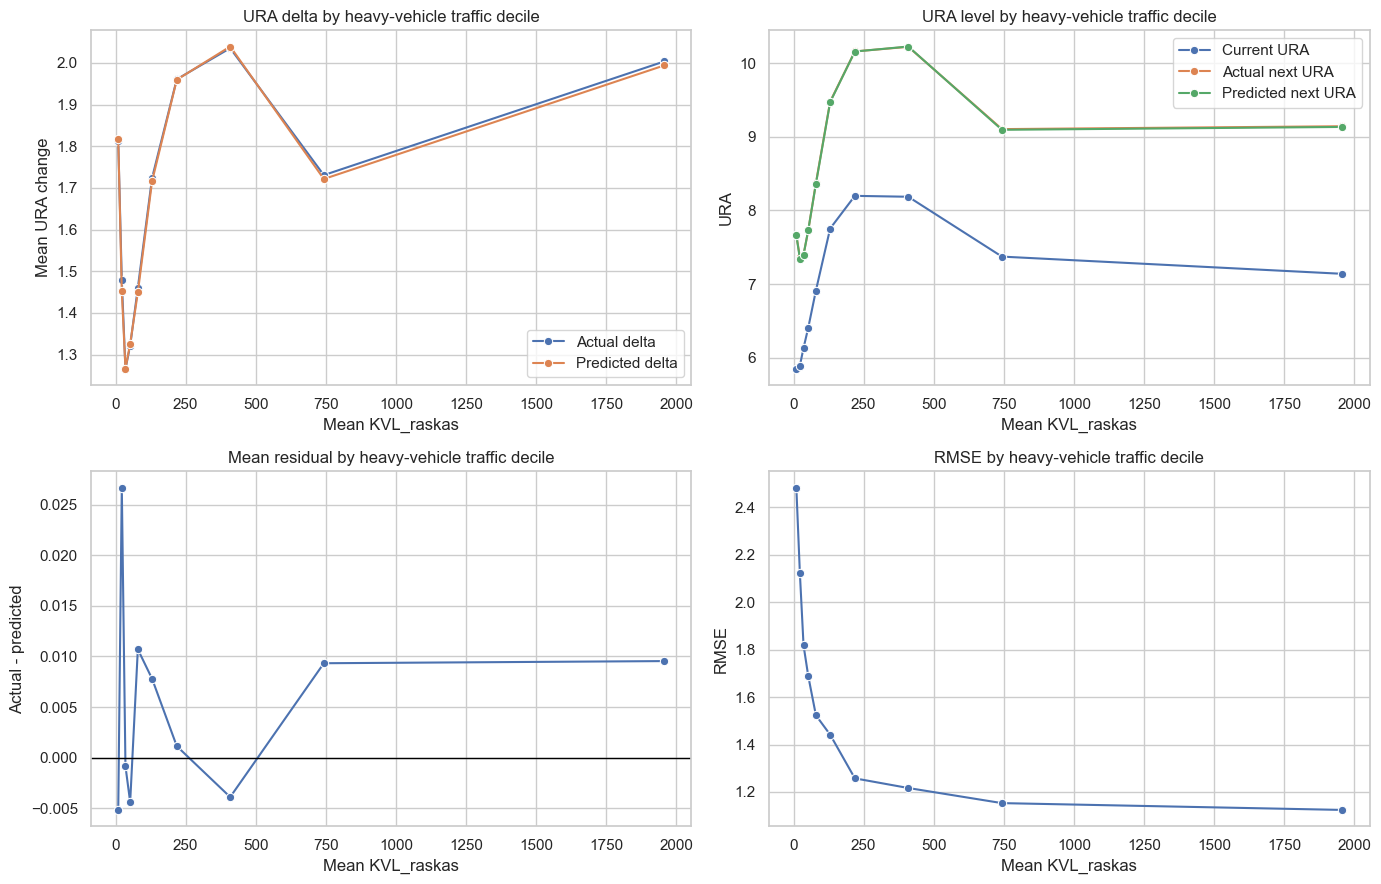

In [10]:
kvl_df = eval_df.dropna(subset=["KVL_raskas"]).copy()
kvl_df["KVL_raskas_bin"] = pd.qcut(kvl_df["KVL_raskas"], q=10, duplicates="drop")

kvl_summary = kvl_df.groupby("KVL_raskas_bin", observed=False).agg(
    rows=(TARGET, "size"),
    mean_KVL_raskas=("KVL_raskas", "mean"),
    median_KVL_raskas=("KVL_raskas", "median"),
    mean_KVL=("KVL", "mean"),
    mean_current_URA=("URA", "mean"),
    mean_actual_target=(TARGET, "mean"),
    mean_prediction=("prediction", "mean"),
    mean_actual_delta=("actual_delta_URA", "mean"),
    mean_predicted_delta=("predicted_delta_URA", "mean"),
    mean_residual=("residual", "mean"),
    mean_abs_error=("abs_error", "mean"),
    rmse=("residual", lambda x: np.sqrt(np.mean(np.square(x)))),
).reset_index()
display(kvl_summary)
kvl_summary.to_csv(TABLE_DIR / "kvl_raskas_decile_summary.csv", index=False)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
sns.lineplot(data=kvl_summary, x="mean_KVL_raskas", y="mean_actual_delta", marker="o", ax=axes[0, 0], label="Actual delta")
sns.lineplot(data=kvl_summary, x="mean_KVL_raskas", y="mean_predicted_delta", marker="o", ax=axes[0, 0], label="Predicted delta")
axes[0, 0].set_title("URA delta by heavy-vehicle traffic decile")
axes[0, 0].set_xlabel("Mean KVL_raskas")
axes[0, 0].set_ylabel("Mean URA change")

sns.lineplot(data=kvl_summary, x="mean_KVL_raskas", y="mean_current_URA", marker="o", ax=axes[0, 1], label="Current URA")
sns.lineplot(data=kvl_summary, x="mean_KVL_raskas", y="mean_actual_target", marker="o", ax=axes[0, 1], label="Actual next URA")
sns.lineplot(data=kvl_summary, x="mean_KVL_raskas", y="mean_prediction", marker="o", ax=axes[0, 1], label="Predicted next URA")
axes[0, 1].set_title("URA level by heavy-vehicle traffic decile")
axes[0, 1].set_xlabel("Mean KVL_raskas")
axes[0, 1].set_ylabel("URA")

sns.lineplot(data=kvl_summary, x="mean_KVL_raskas", y="mean_residual", marker="o", ax=axes[1, 0])
axes[1, 0].axhline(0, color="black", linewidth=1)
axes[1, 0].set_title("Mean residual by heavy-vehicle traffic decile")
axes[1, 0].set_xlabel("Mean KVL_raskas")
axes[1, 0].set_ylabel("Actual - predicted")

sns.lineplot(data=kvl_summary, x="mean_KVL_raskas", y="rmse", marker="o", ax=axes[1, 1])
axes[1, 1].set_title("RMSE by heavy-vehicle traffic decile")
axes[1, 1].set_xlabel("Mean KVL_raskas")
axes[1, 1].set_ylabel("RMSE")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "kvl_raskas_observed_and_predicted_patterns.png", dpi=160)
plt.show()

## 11. Counterfactual Model Response To `KVL_raskas`

,KVL_raskas,mean_raw_model_prediction,mean_predicted_target,mean_predicted_delta_URA,p10_predicted_delta_URA,p90_predicted_delta_URA
0,3.0,1.854506,8.862694,1.854506,0.621351,3.209034
1,10.0,1.850395,8.858583,1.850395,0.671432,3.166790
2,16.0,1.735802,8.743990,1.735802,0.568872,3.019916
3,35.0,1.661432,8.669620,1.661432,0.495657,2.946788
4,101.0,1.742655,8.750843,1.742655,0.579928,3.054088
5,403.0,1.617694,8.625882,1.617694,0.421210,2.973003
6,969.0,1.539283,8.547471,1.539283,0.354845,2.855193
7,1657.0,1.589971,8.598159,1.589971,0.398114,2.927929
8,3061.0,1.964392,8.972580,1.964392,0.748040,3.314745


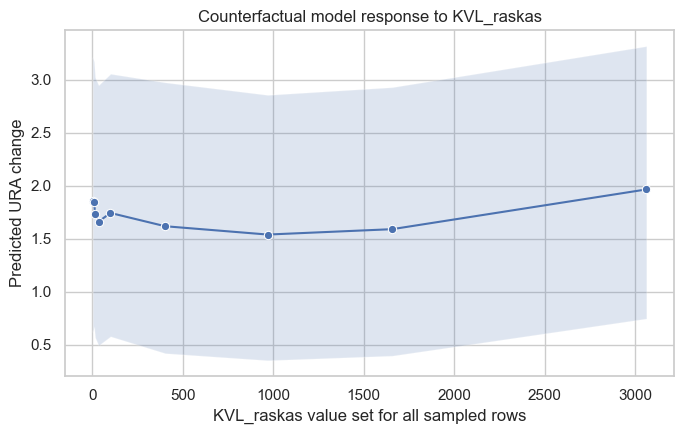

Interpretation note:
This curve shows the fitted model response when KVL_raskas is changed while all other features are held fixed.
It should be interpreted as model behavior, not as causal evidence about heavy vehicles.


In [11]:
response_base = test_frame.dropna(subset=["KVL_raskas"]).sample(min(50_000, test_frame["KVL_raskas"].notna().sum()), random_state=RANDOM_STATE).copy()
kvl_grid = np.unique(np.nanquantile(test_frame["KVL_raskas"], [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]))

response_rows = []
for value in kvl_grid:
    tmp = response_base.copy()
    tmp["KVL_raskas"] = value
    raw = pipeline.predict(tmp[FEATURES])
    pred_actual = convert_prediction(tmp, raw)
    response_rows.append({
        "KVL_raskas": value,
        "mean_raw_model_prediction": float(np.mean(raw)),
        "mean_predicted_target": float(np.mean(pred_actual)),
        "mean_predicted_delta_URA": float(np.mean(pred_actual - tmp["URA"].to_numpy())),
        "p10_predicted_delta_URA": float(np.quantile(pred_actual - tmp["URA"].to_numpy(), 0.10)),
        "p90_predicted_delta_URA": float(np.quantile(pred_actual - tmp["URA"].to_numpy(), 0.90)),
    })

response_df = pd.DataFrame(response_rows)
display(response_df)
response_df.to_csv(TABLE_DIR / "kvl_raskas_counterfactual_response.csv", index=False)

plt.figure(figsize=(7, 4.5))
sns.lineplot(data=response_df, x="KVL_raskas", y="mean_predicted_delta_URA", marker="o")
plt.fill_between(response_df["KVL_raskas"], response_df["p10_predicted_delta_URA"], response_df["p90_predicted_delta_URA"], alpha=0.18)
plt.title("Counterfactual model response to KVL_raskas")
plt.xlabel("KVL_raskas value set for all sampled rows")
plt.ylabel("Predicted URA change")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "kvl_raskas_counterfactual_response.png", dpi=160)
plt.show()

print("Interpretation note:")
print("This curve shows the fitted model response when KVL_raskas is changed while all other features are held fixed.")
print("It should be interpreted as model behavior, not as causal evidence about heavy vehicles.")

## 12. Optional Permutation Importance On Test Sample

This is slower than the other sections. It estimates how much each raw input feature matters for final actual-scale predictions on a sampled test subset.

In [12]:
RUN_PERMUTATION_IMPORTANCE = False

if RUN_PERMUTATION_IMPORTANCE:
    importance_sample = test_frame.sample(min(len(test_frame), 30_000), random_state=RANDOM_STATE).copy()
    y_true = importance_sample[TARGET].to_numpy()

    class ActualScalePredictor:
        def __init__(self, pipe):
            self.pipe = pipe
        def predict(self, X):
            raw = self.pipe.predict(X[FEATURES])
            if TARGET_TYPE == "delta_converted_to_actual":
                return X[CURRENT_TARGET_COL].to_numpy() + raw
            return raw

    wrapped = ActualScalePredictor(pipeline)
    pi = permutation_importance(
        wrapped, importance_sample[FEATURES], y_true,
        scoring="neg_root_mean_squared_error",
        n_repeats=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    importance_df = pd.DataFrame({
        "feature": FEATURES,
        "importance_mean": pi.importances_mean,
        "importance_std": pi.importances_std,
    }).sort_values("importance_mean", ascending=False)
    display(importance_df)
    importance_df.to_csv(TABLE_DIR / "permutation_importance.csv", index=False)

    plt.figure(figsize=(8, 6))
    sns.barplot(data=importance_df.head(20), y="feature", x="importance_mean", color="#4C78A8")
    plt.title("Permutation importance, sampled test set")
    plt.xlabel("Increase in RMSE when permuted")
    plt.ylabel("")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "permutation_importance.png", dpi=160)
    plt.show()
else:
    print("Permutation importance skipped. Set RUN_PERMUTATION_IMPORTANCE=True to run it.")

Permutation importance skipped. Set RUN_PERMUTATION_IMPORTANCE=True to run it.


## 13. Save Evaluation Manifest

In [13]:
manifest = {
    "model_path": str(PIPELINE_PATH),
    "metadata_path": str(METADATA_PATH),
    "target": TARGET,
    "target_type": TARGET_TYPE,
    "features": FEATURES,
    "rows_evaluated": int(len(eval_df)),
    "overall_metrics": overall_result.iloc[0].to_dict(),
    "figure_dir": str(FIGURE_DIR),
    "table_dir": str(TABLE_DIR),
}
with open(RESULT_DIR / "evaluation_manifest.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

print(f"Saved evaluation manifest to {RESULT_DIR / 'evaluation_manifest.json'}")
print(f"Saved tables to {TABLE_DIR.resolve()}")
print(f"Saved figures to {FIGURE_DIR.resolve()}")

Saved evaluation manifest to results\final_model_evaluation\evaluation_manifest.json
Saved tables to C:\Users\Gamer2\Documents\school_sync\misc_maisteri_kurssit\case_studies_operations_research\Vayla_projekti\results\final_model_evaluation\tables
Saved figures to C:\Users\Gamer2\Documents\school_sync\misc_maisteri_kurssit\case_studies_operations_research\Vayla_projekti\results\final_model_evaluation\figures
